# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [195]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [196]:
df = pd.read_csv('data/AviationData_Cleaned.csv', encoding='latin1', low_memory=False)

In [197]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Publication.Date',
       'Total.Passengers', 'Fatal_Serious_Count', 'Aircraft_Destroyed',
       'Plane_Type'],
      dtype='object')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types.

In [198]:

#Getting airplane capacity
df["Plane_Type"].value_counts().head(50)

Plane_Type
CESSNA 172                 763
CESSNA 152                 311
CESSNA 182                 300
CESSNA 172S                272
PIPER PA28                 268
CESSNA 172N                249
CESSNA 180                 212
CESSNA 172M                179
CESSNA 150                 177
PIPER PA-18-150            175
PIPER PA-28-140            169
BEECH A36                  164
CESSNA 172P                141
CIRRUS DESIGN CORP SR22    137
BOEING 737                 118
CESSNA 140                 116
CESSNA 172R                108
CESSNA 170B                107
PIPER PA-28-180            105
PIPER PA-28-161            101
CESSNA 210                  95
MOONEY M20J                 92
PIPER PA-28-181             92
CIRRUS SR22                 91
CESSNA A185F                90
AERONCA 7AC                 89
PIPER PA18                  86
PIPER PA-18                 80
CESSNA 208B                 78
CESSNA 182P                 78
CESSNA 177                  76
CESSNA 170                  

In [199]:
# 1. Define keywords for explicit classification
small_keywords = [
    "CESSNA", "PIPER", "BEECH", "MOONEY", "MAULE", "AERONCA", 
    "LUSCOMBE", "CHAMPION", "STINSON", "TAYLORCRAFT", "GRUMMAN", "CIRRUS"
]

large_keywords = [
    "BOEING", "AIRBUS", "ATR", "EMBRAER", "MCDONNELL", 
    "DOUGLAS", "SAAB", "FOKKER", "DHC", "BOMBARDIER"
]

def classify_plane(aircraft):
    aircraft = str(aircraft).upper()

    if any(keyword in aircraft for keyword in small_keywords):
        return "Small"

    if any(keyword in aircraft for keyword in large_keywords):
        return "Large"

    return "Unknown"


df["Plane_Size"] = df["Plane_Type"].apply(classify_plane)
print(df["Plane_Size"].value_counts())

# Remove unclassified aircraft to keep the data clean
df_analysis = df[df["Plane_Size"] != "Unknown"].copy()

df_analysis["Plane_Size"].value_counts()

Plane_Size
Small      14246
Unknown     1363
Large        941
Name: count, dtype: int64


Plane_Size
Small    14246
Large      941
Name: count, dtype: int64

In [200]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Publication.Date',
       'Total.Passengers', 'Fatal_Serious_Count', 'Aircraft_Destroyed',
       'Plane_Type', 'Plane_Size'],
      dtype='object')

In [201]:
#Creating Safety Metric
df_analysis["Total_Occupants"] = (
    df_analysis["Total.Fatal.Injuries"] + 
    df_analysis["Total.Serious.Injuries"] + 
    df_analysis["Total.Minor.Injuries"] + 
    df_analysis["Total.Uninjured"]
).astype(float)

# Create the Fatal/Serious Injury Rate 
df_analysis["Fatal_Serious_Rate"] = (
    df_analysis["Fatal_Serious_Count"] / df_analysis["Total_Occupants"]
)
df_analysis["Fatal_Serious_Rate"] = df_analysis["Fatal_Serious_Rate"].fillna(0)




In [202]:
# Summarize and find the safest SMALL aircraft (Minimum 20 incidents)
small_summary = (
    df_analysis[df_analysis["Plane_Size"] == "Small"]
    .groupby("Make")
    .agg(
        Mean_Fatal_Serious_Rate=("Fatal_Serious_Rate", "mean"),
        Mean_Destroyed_Rate=("Aircraft_Destroyed", "mean"),
        Accidents=("Make", "count")
    )
)

small_summary = small_summary[small_summary["Accidents"] >= 20].sort_values("Mean_Fatal_Serious_Rate")
print("--- TOP SAFEST SMALL PLANE MANUFACTURERS ---")
print(small_summary.head(15))



--- TOP SAFEST SMALL PLANE MANUFACTURERS ---
                                Mean_Fatal_Serious_Rate  Mean_Destroyed_Rate  \
Make                                                                           
MAULE                                          0.164806             0.041860   
GRUMMAN ACFT ENG COR-SCHWEIZER                 0.206897             0.017241   
STINSON                                        0.216408             0.023256   
AERONCA                                        0.225833             0.035000   
CHAMPION                                       0.262208             0.076433   
CESSNA                                         0.264918             0.096600   
AMERICAN CHAMPION AIRCRAFT                     0.274510             0.039216   
LUSCOMBE                                       0.280142             0.014184   
PIPER                                          0.295606             0.113002   
TAYLORCRAFT                                    0.306452             0.03225

In [203]:
# Summarize and find the safest LARGE aircraft (Minimum 20 incidents)
large_summary = (
    df_analysis[df_analysis["Plane_Size"] == "Large"]
    .groupby("Make")
    .agg(
        Mean_Fatal_Serious_Rate=("Fatal_Serious_Rate", "mean"),
        Mean_Destroyed_Rate=("Aircraft_Destroyed", "mean"),
        Accidents=("Make", "count")
    )
)

large_summary = large_summary[large_summary["Accidents"] >= 20].sort_values("Mean_Fatal_Serious_Rate")
print("\n--- TOP SAFEST LARGE PLANE MANUFACTURERS ---")
print(large_summary.head(15))


--- TOP SAFEST LARGE PLANE MANUFACTURERS ---
                   Mean_Fatal_Serious_Rate  Mean_Destroyed_Rate  Accidents
Make                                                                      
MCDONNELL DOUGLAS                 0.049034             0.121212         66
BOEING                            0.117746             0.095841        553
AIRBUS                            0.163090             0.146341         82
DEHAVILLAND                       0.238337             0.024390         82
EMBRAER                           0.274151             0.193878         98
DE HAVILLAND                      0.351744             0.183333         60


Aircraft were split into small and large groups based on their type, as seating data was missing. Safety was measured by injury and destruction rates. To ensure reliable data, we only included aircraft types with 20 or more accidents.

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [204]:
#Analysing safest small makes
small_makes = (
    df_analysis[df_analysis["Plane_Size"] == "Small"]
    .groupby("Make")
    .agg(
        Mean_Fatal_Serious=("Fatal_Serious_Rate", "mean"),
        Accidents=("Make", "count")
    )
)

small_makes = small_makes[small_makes["Accidents"] >= 20]

small_top15 = (
    small_makes
    .sort_values("Mean_Fatal_Serious")
    .head(15)
)

In [205]:
#Analyzing safest large makes
large_makes = (
    df_analysis[df_analysis["Plane_Size"] == "Large"]
    .groupby("Make")
    .agg(
        Mean_Fatal_Serious=("Fatal_Serious_Rate", "mean"),
        Accidents=("Make", "count")
    )
)

large_makes = large_makes[large_makes["Accidents"] >= 20]

large_top15 = (
    large_makes
    .sort_values("Mean_Fatal_Serious")
    .head(15)
)

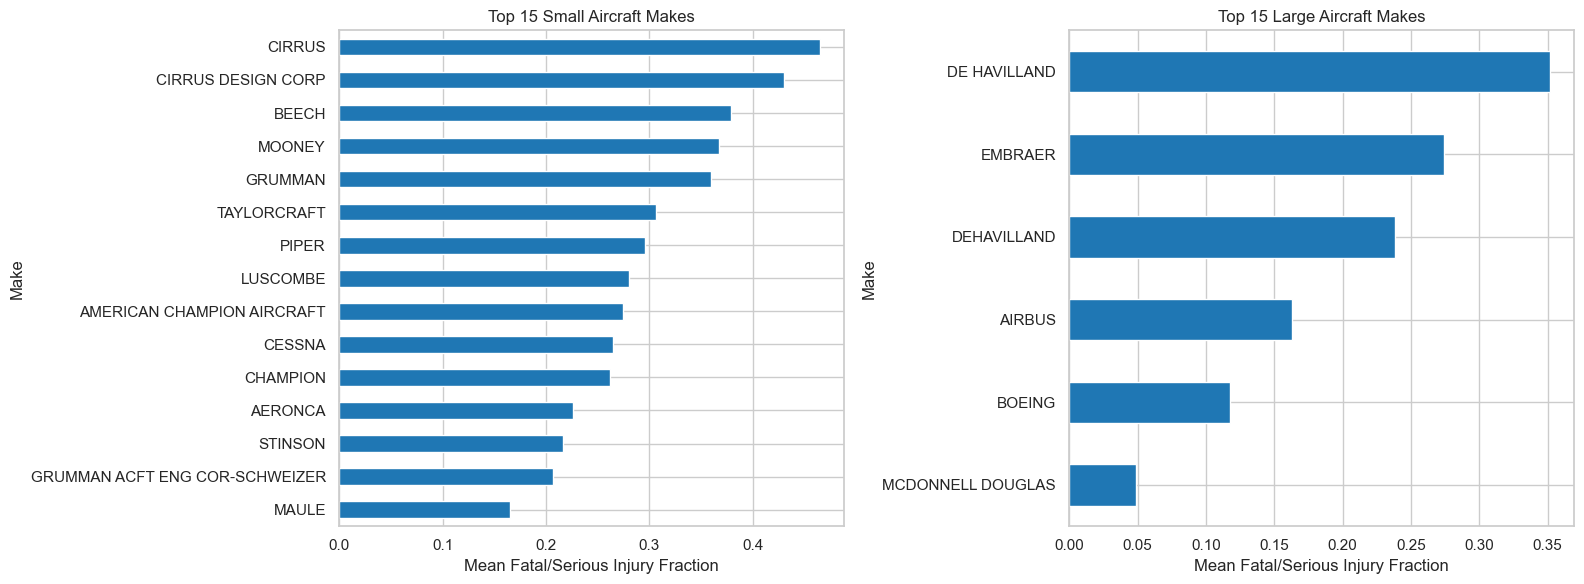

In [206]:
#Plotting safest smallest and safest largest side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

small_top15["Mean_Fatal_Serious"].plot(
    kind="barh",
    ax=axes[0]
)

axes[0].set_title("Top 15 Small Aircraft Makes")
axes[0].set_xlabel("Mean Fatal/Serious Injury Fraction")

large_top15["Mean_Fatal_Serious"].plot(
    kind="barh",
    ax=axes[1]
)

axes[1].set_title("Top 15 Large Aircraft Makes")
axes[1].set_xlabel("Mean Fatal/Serious Injury Fraction")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [207]:
#Getting the safest 10 small makes
small_top10 = (
    df_analysis[df_analysis["Plane_Size"] == "Small"]
    .groupby("Make")["Fatal_Serious_Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

#Filtering the data
small_violin = df_analysis [
    (df_analysis["Plane_Size"] == "Small") &
    (df_analysis["Make"].isin(small_top10))
]

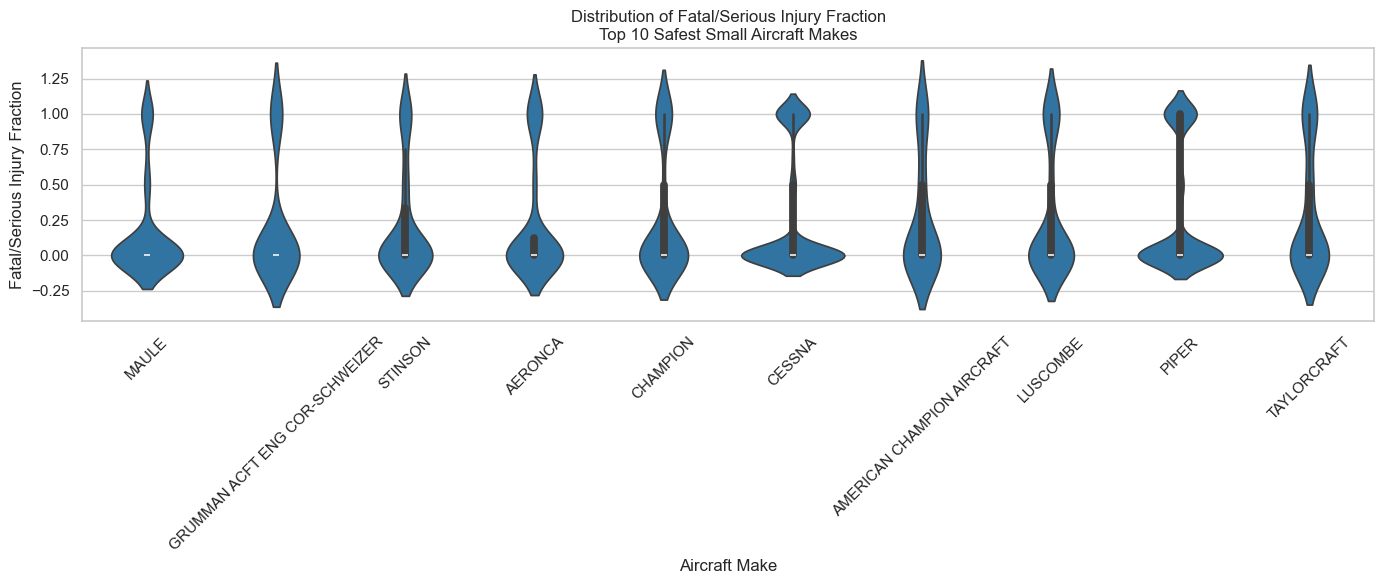

In [208]:

#Plotting data in a violinplot
plt.figure(figsize=(14,6))

sns.violinplot(
    data=small_violin,
    x="Make",
    y="Fatal_Serious_Rate",
    order=small_top10
)

plt.title("Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal/Serious Injury Fraction")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [209]:
#Getting the 10 safest large makes
large_top10 = (
    df_analysis[df_analysis["Plane_Size"] == "Large"]
    .groupby("Make")["Fatal_Serious_Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

#Filtering data
large_strip = df_analysis[
    (df_analysis["Plane_Size"] == "Large") &
    (df_analysis["Make"].isin(large_top10))
]

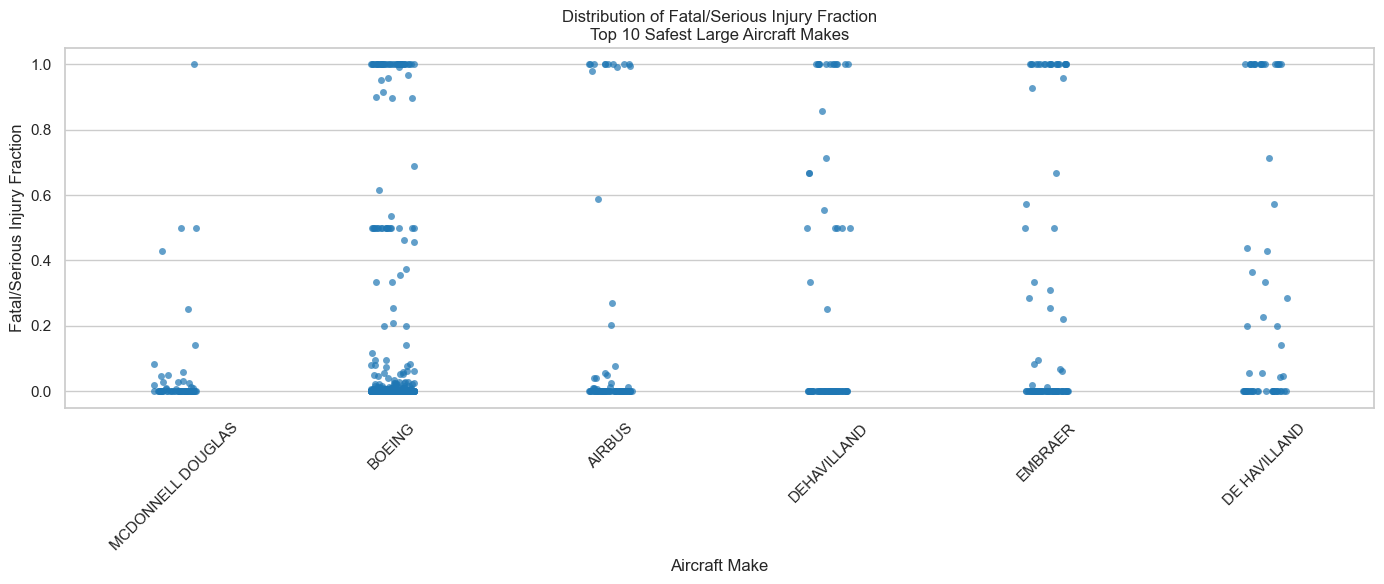

In [210]:
#Plotting Strip Plot
plt.figure(figsize=(14,6))

sns.stripplot(
    data=large_strip,
    x="Make",
    y="Fatal_Serious_Rate",
    order=large_top10,
    jitter=True,
    alpha=0.7
)

plt.title("Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Large Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal/Serious Injury Fraction")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [211]:
#Small aircraft
small_destroyed = (
    df_analysis[df_analysis["Plane_Size"] == "Small"]
    .groupby("Make")
    .agg(
        Mean_Destruction_Rate=("Aircraft_Destroyed", "mean"),
        Accidents=("Make", "count")
    )
)

# Keep makes with a reasonable number of accidents
small_destroyed = small_destroyed[small_destroyed["Accidents"] >= 20]

small_destroyed = (
    small_destroyed
    .sort_values("Mean_Destruction_Rate")
    .head(15)
)

small_destroyed

,Mean_Destruction_Rate,Accidents
Make,,
LUSCOMBE,0.014184,141
GRUMMAN ACFT ENG COR-SCHWEIZER,0.017241,58
STINSON,0.023256,129
TAYLORCRAFT,0.032258,93
AERONCA,0.035000,200
AMERICAN CHAMPION AIRCRAFT,0.039216,51
MAULE,0.041860,215
CHAMPION,0.076433,157
CESSNA,0.096600,7029


In [212]:
#Large aircraft
large_destroyed = (
    df_analysis[df_analysis["Plane_Size"] == "Large"]
    .groupby("Make")
    .agg(
        Mean_Destruction_Rate=("Aircraft_Destroyed", "mean"),
        Accidents=("Make", "count")
    )
)

large_destroyed = large_destroyed[large_destroyed["Accidents"] >= 20]

large_destroyed = (
    large_destroyed
    .sort_values("Mean_Destruction_Rate")
    .head(15)
)

large_destroyed

,Mean_Destruction_Rate,Accidents
Make,,
DEHAVILLAND,0.024390,82
BOEING,0.095841,553
MCDONNELL DOUGLAS,0.121212,66
AIRBUS,0.146341,82
DE HAVILLAND,0.183333,60
EMBRAER,0.193878,98


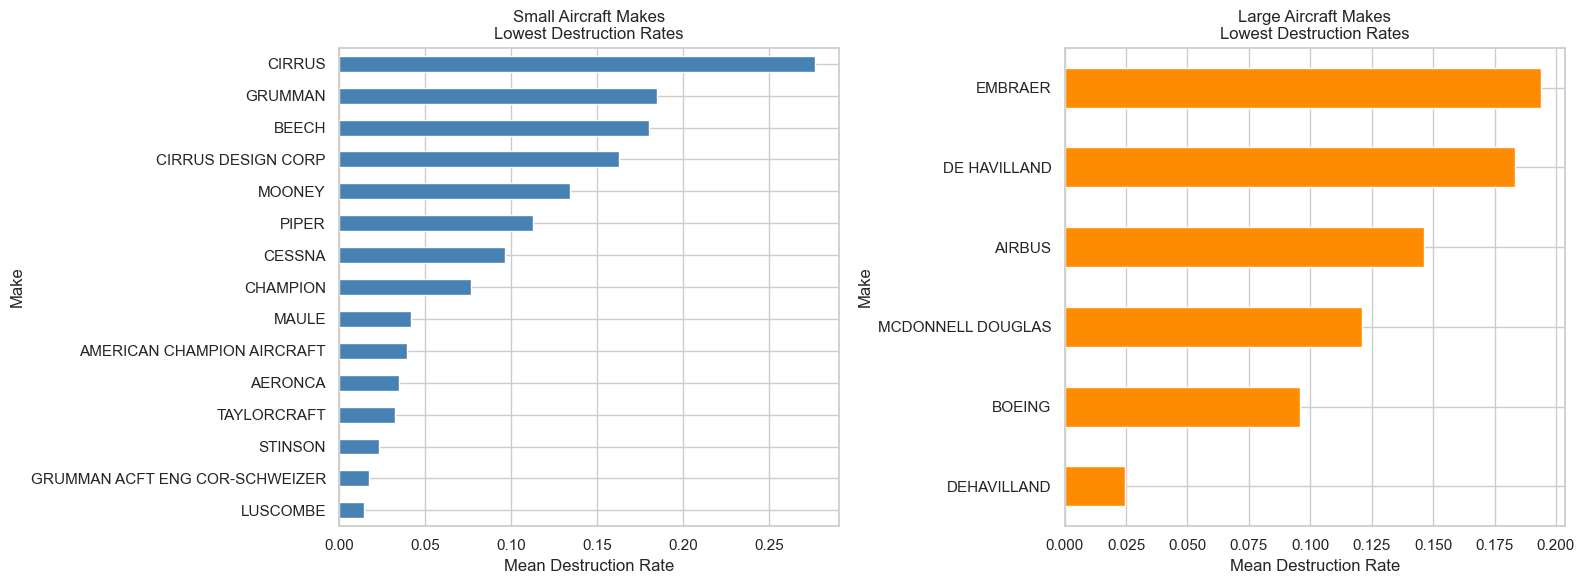

In [213]:
#Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

small_destroyed["Mean_Destruction_Rate"].plot(
    kind="barh",
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Small Aircraft Makes\nLowest Destruction Rates")
axes[0].set_xlabel("Mean Destruction Rate")

large_destroyed["Mean_Destruction_Rate"].plot(
    kind="barh",
    ax=axes[1],
    color="darkorange"
)

axes[1].set_title("Large Aircraft Makes\nLowest Destruction Rates")
axes[1].set_xlabel("Mean Destruction Rate")

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Safety Analysis by Aircraft Manufacturer (Make)

This analysis evaluates manufacturer safety profiles across small and large aircraft using average injury rates, aircraft destruction rates, and accident distributions.

#### Key Findings & Statistical Commentary

* **Small Aircraft (High-Volume vs. Outliers):** 
  * **Cessna** (7,029 accidents) and **Piper** (3,938 accidents) dominate the dataset. Their massive sample sizes make their baseline metrics (~26–29% injury rates, ~10–11% destruction rates) the most reliable standards for small planes.
  * **Cirrus** models show the highest risk profile among small aircraft, with injury rates exceeding 43% and a 27.6% destruction rate.
  * **Distribution Shapes:** The violin plots show that small aircraft accidents mostly group near a 0.0 injury fraction (meaning many accidents have zero serious injuries), but they feature extended, thin lines all the way to 1.0, showing that highly severe outcomes still occur across all makes.

* **Large Aircraft (Commercial Fleets):**
  * **Boeing** offers the most statistically robust baseline for large planes (553 accidents), maintaining a low injury rate (~11.8%) and destruction rate (~9.6%).
  * **McDonnell Douglas** yields the lowest injury rate (~4.9%), though its destruction rate is slightly higher (~12.1%).
  * **Distribution Shapes:** The scatter/jitter plots for large planes reveal dense clusters at 0.0 (no injuries), with sparse points at 1.0. This indicates that commercial aircraft accidents are highly survivable, with severe injuries being rare exceptions.

#### 💡 Recommendations

* **Top Recommendations for Small Aircraft:**
  * **Maule** and **Grumman-Schweizer** are excellent options for safety, posting the lowest overall injury rates (~16% and ~21%) alongside exceptionally low destruction rates.
  * For buyers prioritizing structural integrity, **Luscombe** and **Grumman-Schweizer** keep destruction rates under 2%.

* **Top Recommendations for Large Aircraft:**
  * **Boeing** is highly recommended due to its proven, stable safety performance across a massive fleet history.
  * **Dehavilland** is an outstanding choice for structural durability, recording a remarkably low destruction rate of just 2.4%.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [214]:
large_types = (
    df_analysis[df_analysis["Plane_Size"] == "Large"]
    .groupby("Plane_Type")
    .agg(
        Mean_Fatal_Serious=("Fatal_Serious_Rate", "mean"),
        Accidents=("Plane_Type", "count")
    )
)

large_types = large_types[large_types["Accidents"] >= 10]

large_top10_types = (
    large_types
    .sort_values("Mean_Fatal_Serious")
    .head(10)
)

large_top10_types

,Mean_Fatal_Serious,Accidents
Plane_Type,,
BOEING 777,0.001426,19
BOEING 757,0.001657,16
EMBRAER EMB-145LR,0.059091,11
BOEING 737 7H4,0.068121,14
BOEING 737,0.119933,118
BOEING 747,0.132634,17
BOEING 767,0.132675,26
BOEING A75N1(PT17),0.139785,31
BOEING A75N1,0.187500,16


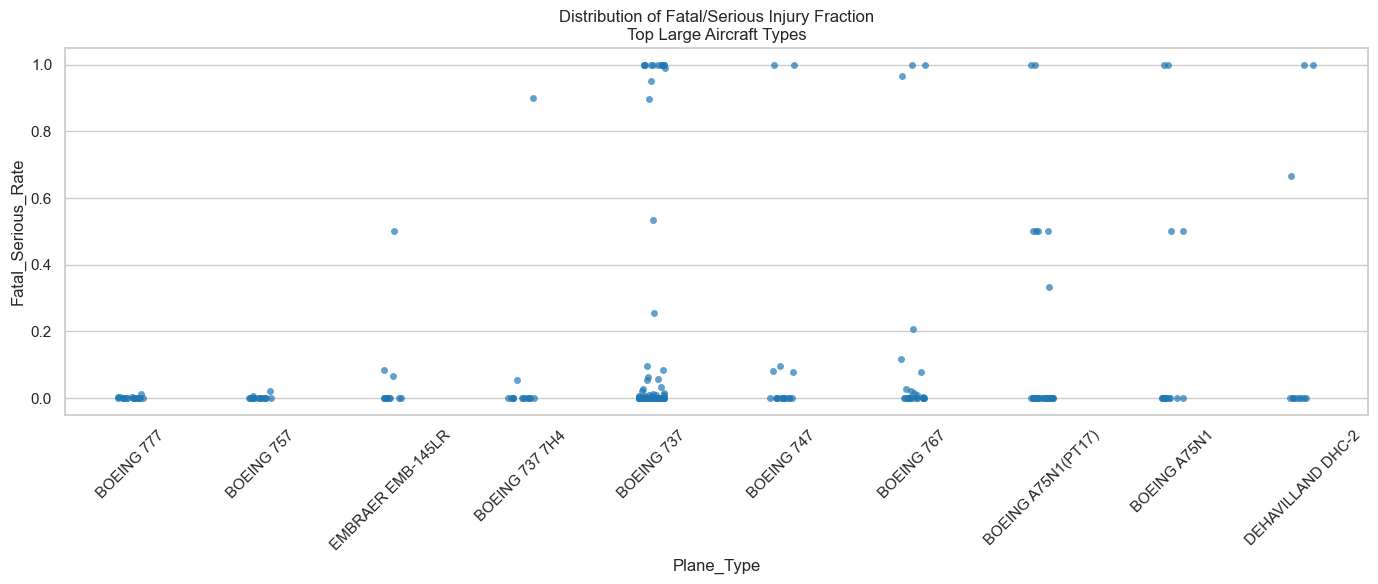

In [215]:
#Distribution plot for large aircrafts
large_dist = df_analysis[
    (df_analysis["Plane_Size"] == "Large") &
    (df_analysis["Plane_Type"].isin(large_top10_types.index))
]

plt.figure(figsize=(14,6))

sns.stripplot(
    data=large_dist,
    x="Plane_Type",
    y="Fatal_Serious_Rate",
    order=large_top10_types.index,
    jitter=True,
    alpha=0.7
)

plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction\nTop Large Aircraft Types")
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [216]:
small_types = (
    df_analysis[df_analysis["Plane_Size"] == "Small"]
    .groupby("Plane_Type")
    .agg(
        Mean_Fatal_Serious=("Fatal_Serious_Rate", "mean"),
        Accidents=("Plane_Type", "count")
    )
)

# Keep only aircraft types with at least 10 accidents
small_types = small_types[small_types["Accidents"] >= 10]

# Select the 10 safest aircraft types
small_top10_types = (
    small_types
    .sort_values("Mean_Fatal_Serious")
    .head(10)
)

small_top10_types

,Mean_Fatal_Serious,Accidents
Plane_Type,,
CESSNA 172SP,0.000000,12
MAULE M-5-210C,0.000000,11
CESSNA 180J,0.037037,27
CESSNA A185E,0.038889,18
PIPER PA-20,0.040000,25
BEECH B19,0.041667,16
CESSNA 180H,0.049020,34
CESSNA 195,0.049550,37
PIPER PA-32-301,0.050000,20


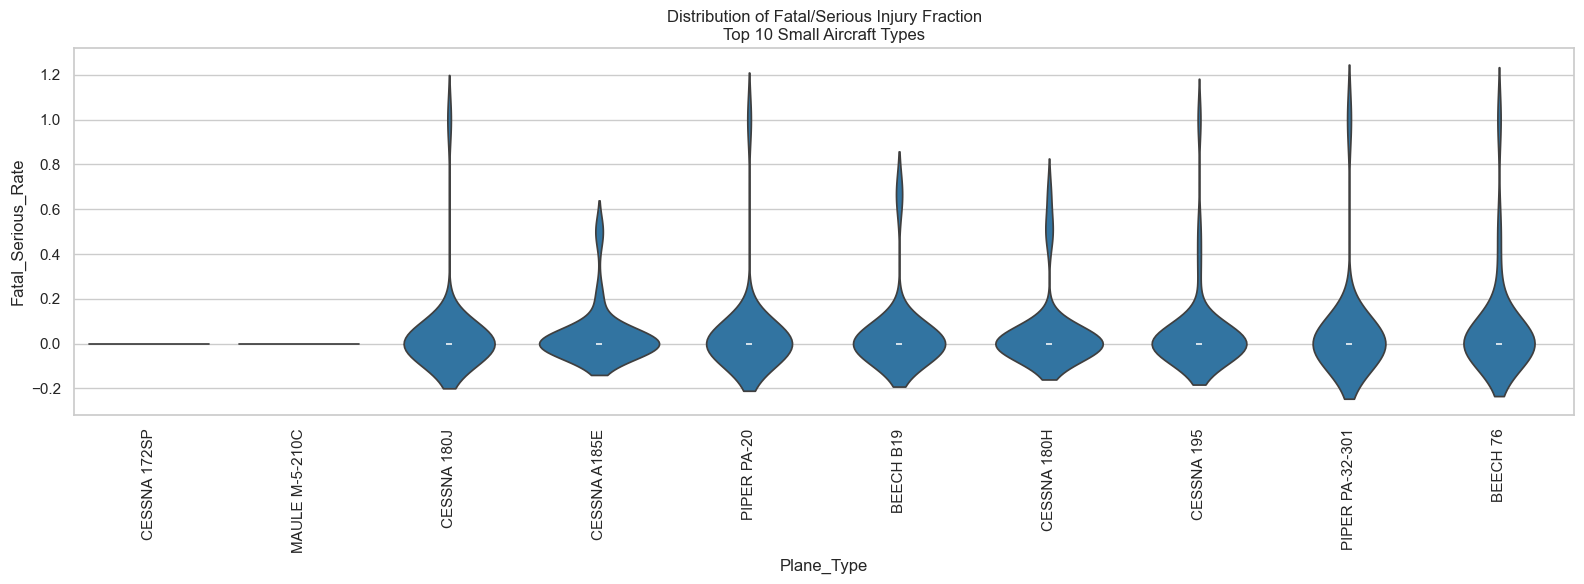

In [217]:
#Distribution Plot for small aircrafts
small_dist = df_analysis[
    (df_analysis["Plane_Size"] == "Small") &
    (df_analysis["Plane_Type"].isin(small_top10_types.index))
]

plt.figure(figsize=(16,6))

sns.violinplot(
    data=small_dist,
    x="Plane_Type",
    y="Fatal_Serious_Rate",
    order=small_top10_types.index
)

plt.xticks(rotation=90)
plt.title("Distribution of Fatal/Serious Injury Fraction\nTop 10 Small Aircraft Types")
plt.tight_layout()
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Safety Analysis by Specific Aircraft Models (Plane Type)

This analysis evaluates injury severity rates across individual small and large aircraft models to identify the top-performing types within each class.

#### Key Findings & Statistical Commentary

* **Large Aircraft Models (Commercial Fleets):**
  * **Boeing 777** (19 accidents) and **Boeing 757** (16 accidents) lead the category with exceptionally low average injury rates (~0.14% and ~0.16% respectively). 
  * **Boeing 737** represents the most statistically robust sample with 118 accidents, yielding an average injury rate of ~11.9%. 
  * **Distribution Jitter Plot:** The large plane scatter plot reveals that for models like the Boeing 777 and 757, accidents are heavily concentrated right at the 0.0 line (zero severe injuries). However, for older or smaller commercial configurations like the **Dehavilland DHC-2** or legacy **Boeing A755N1** biplanes, the points scatter vertically toward a 1.0 injury fraction, reflecting higher risk in smaller, non-jet commercial operations.

* **Small Aircraft Models (General Aviation):**
  * **Cessna 172SP** (12 accidents) and **Maule M-5-210C** (11 accidents) recorded a perfect **0.00% average injury rate** across their entire accident history in this slice.
  * Popular standard models like the **Cessna 180J** (27 accidents) and **Piper PA-20** (25 accidents) remain highly survivable with injury rates under 4%.
  * **Distribution Violin Plot:** The small aircraft violins feature a very wide base perfectly centered on 0.0, proving that the vast majority of accidents involve no serious or fatal injuries. However, almost every model has a long, needle-thin tail reaching up to 1.0, indicating that while rare, catastrophic fatal outcomes still happen across the board.

#### Recommendations

* **Top Recommendations for Large Aircraft:**
  * **Boeing 777** and **Boeing 757** are the premier choices for large aircraft passenger safety, as they successfully converted nearly every recorded incident into a zero-injury event.
  * For standard high-frequency fleets, the mainline **Boeing 737** serves as a dependable baseline.

* **Top Recommendations for Small Aircraft:**
  * **Cessna 172SP** is highly recommended for training and general operations, confirming its industry reputation for safety.
  * **Maule M-5-210C** stands out as an exceptional choice for a low-risk, small utility aircraft profile.


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [218]:
weather_summary = (
    df_analysis
    .groupby("Weather.Condition")
    .agg(
        Mean_Fatal_Serious=("Fatal_Serious_Rate", "mean"),
        Mean_Destroyed=("Aircraft_Destroyed", "mean"),
        Accidents=("Weather.Condition", "count")
    )
    .sort_values("Mean_Fatal_Serious", ascending=False)
)

weather_summaryweather_summary = (
    df_analysis
    .groupby("Weather.Condition")
    .agg(
        Mean_Fatal_Serious=("Fatal_Serious_Rate", "mean"),
        Mean_Destroyed=("Aircraft_Destroyed", "mean"),
        Accidents=("Weather.Condition", "count")
    )
    .sort_values("Mean_Fatal_Serious", ascending=False)
)

weather_summary

,Mean_Fatal_Serious,Mean_Destroyed,Accidents
Weather.Condition,,,
IMC,0.644371,0.365854,820
UNK,0.487522,0.360656,183
VMC,0.234052,0.070208,12762


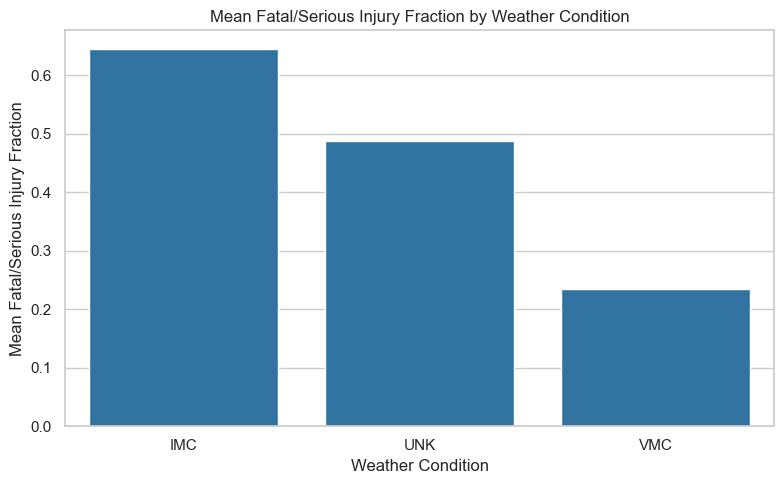

In [219]:
#Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Mean_Fatal_Serious"
)

plt.title("Mean Fatal/Serious Injury Fraction by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Mean Fatal/Serious Injury Fraction")

plt.tight_layout()
plt.show()

Adverse weather directly links to worse accident outcomes. Comparing injury and destruction rates between Instrument (IMC) and Visual (VMC) conditions highlights these risks. Higher rates in IMC prove that low visibility increases accident severity, proving the need for better pilot training and safer decision-making

In [220]:
# display number of engines counts
engine_counts = df['Number.of.Engines'].value_counts().sort_index()
print("=== Number of Engines Distribution ===")
print(engine_counts)

=== Number of Engines Distribution ===
Number.of.Engines
0.0        4
1.0    13138
2.0     1940
3.0       15
4.0       28
Name: count, dtype: int64


In [221]:
engine_summary = (
    df_analysis
    .groupby("Number.of.Engines")
    .agg(
        Mean_Fatal_Serious=("Fatal_Serious_Rate", "mean"),
        Mean_Destroyed=("Aircraft_Destroyed", "mean"),
        Accidents=("Number.of.Engines", "count")
    )
    .sort_values("Mean_Fatal_Serious", ascending=False)
)

engine_summary


,Mean_Fatal_Serious,Mean_Destroyed,Accidents
Number.of.Engines,,,
2.0,0.319794,0.172673,1859
0.0,0.285714,0.250000,4
1.0,0.254267,0.075489,11962
4.0,0.248384,0.214286,28
3.0,0.126792,0.066667,15


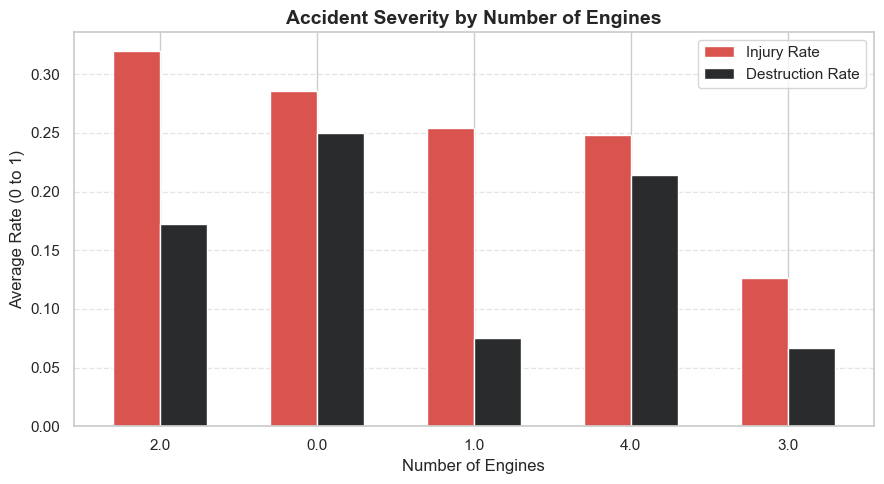

In [222]:


# 2. Create the grouped bar chart
ax = engine_summary[["Mean_Fatal_Serious", "Mean_Destroyed"]].plot(
    kind="bar", 
    figsize=(9, 5), 
    width=0.6, 
    color=["#d9534f", "#292b2c"]
)

# 3. Customize labels and design
plt.title("Accident Severity by Number of Engines", fontsize=14, fontweight="bold")
plt.xlabel("Number of Engines", fontsize=12)
plt.ylabel("Average Rate (0 to 1)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(["Injury Rate", "Destruction Rate"], loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#### Sample Size Warning
The dataset is heavily skewed by unequal sample sizes:
* **1.0 and 2.0 Engines:** Make up **99.7% of the data** (15,078 accidents). These trends are statistically reliable.
* **0.0, 3.0, and 4.0 Engines:** Combined, these account for just 47 total accidents. Because these sample sizes are so small, a single crash heavily distorts the averages, making these categories unreliable for safety trends.

#### Takeaways
* **Single vs. Twin Engines:** Accidents involving twin-engine aircraft (2.0) result in higher average injury rates (~32%) and destruction rates (~17%) than single-engine aircraft (~25% injury, ~7% destruction).
* **Statistical Noise:** The massive spikes and drops seen in the 0.0, 3.0, and 4.0 engine categories are artifacts of their low sample sizes rather than proof of inherent aircraft safety.